# Finding the right bed topography of Eqip

               X             Y        lat        lon             season  \
0 -184567.090892 -2.228222e+06  69.571554 -49.735089  2008_Greenland_TO   
1 -184567.341771 -2.228192e+06  69.571822 -49.735159  2008_Greenland_TO   
2 -184567.640690 -2.228162e+06  69.572089 -49.735230  2008_Greenland_TO   
3 -184567.930314 -2.228132e+06  69.572357 -49.735301  2008_Greenland_TO   
4 -184568.258754 -2.228102e+06  69.572625 -49.735373  2008_Greenland_TO   

       segment  frm    utc_date  utc_time      gps_time        Dist      elev  \
0  20080710_05   11  2008/07/10  19:26:54  1.215718e+09    0.000000  1759.546   
1  20080710_05   11  2008/07/10  19:26:54  1.215718e+09   30.062641  1759.406   
2  20080710_05   11  2008/07/10  19:26:55  1.215718e+09   60.017592  1759.284   
3  20080710_05   11  2008/07/10  19:26:55  1.215718e+09   90.083748  1759.186   
4  20080710_05   11  2008/07/10  19:26:55  1.215718e+09  120.153498  1759.116   

   surface    Eqip  bottom   WGS84_ATM    ATM_Eqip  ATM_Bottom

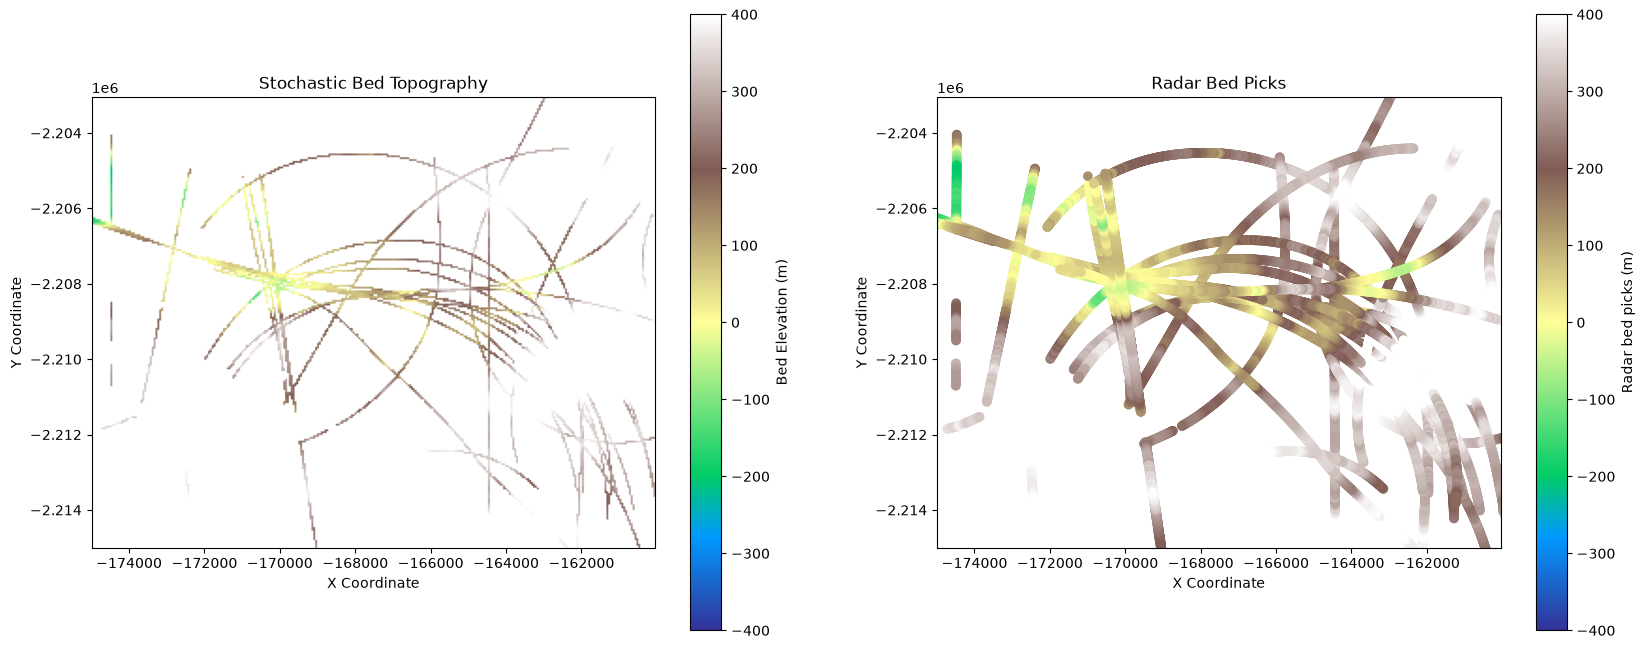

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../')


stochastic_bed_path = '../data/stochastic-beds/*.csv'
bed_picks_path      = '../data/picks/Eqip_BedPicks.csv'

# load the bed picks
bed_picks = pd.read_csv(bed_picks_path)

print(bed_picks.head())

# load a stochastic bed for reference
stochastic_bed = pd.read_csv(stochastic_bed_path.replace('*', 'SGS_realization_1_data'))

# count unique 'segment' in the pandas table, segments are strings
unique_segments = bed_picks['segment'].nunique()
print(f'Number of unique segments in the bed picks: {unique_segments}')
# get all the unique segment strings
unique_segment_strings = bed_picks['segment'].unique()

# first plot the stochastic bed
extent = [stochastic_bed['X'].min(), stochastic_bed['X'].max(), stochastic_bed['Y'].min(), stochastic_bed['Y'].max()]
x_grid = np.unique(stochastic_bed['X'])
y_grid = np.unique(stochastic_bed['Y'])
X, Y = np.meshgrid(x_grid, y_grid)
Z_interp = stochastic_bed.pivot(index='Y', columns='X', values='bottom').values

plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(Z_interp, extent=extent, origin='lower', cmap='terrain', vmin=-400, vmax=400)
plt.colorbar(label='Bed Elevation (m)')
plt.title('Stochastic Bed Topography')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

# plot all the bed picks
plt.subplot(1, 2, 2)
plt.imshow(Z_interp, extent=extent, origin='lower', cmap='terrain', vmin=-400, vmax=400, alpha=0.5)
plt.scatter(bed_picks['X'], bed_picks['Y'], c=bed_picks['bottom'], 
            cmap='terrain', vmin=-400, vmax=400,
            label='Bed Picks')
plt.xlim(extent[0], extent[1])
plt.ylim(extent[2], extent[3])
plt.colorbar(label='Radar bed picks (m)')
plt.title('Radar Bed Picks')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

#### Save all tracks separately for inspections

In [2]:
# break up bed_picks between when Dist == 0
bed_picks_pieces = (bed_picks['Dist'] == 0).cumsum()
bed_picks_grouped = bed_picks.groupby(bed_picks_pieces)

# plot by the group on top of the stochastic bed
for name, group in bed_picks_grouped:
    segment_name = group['segment'].iloc[0]
    plt.figure(figsize=(10, 8))
    plt.imshow(Z_interp, extent=extent, origin='lower', cmap='terrain', vmin=-400, vmax=400,alpha=0.5)
    plt.colorbar(label='Bed Elevation (m)')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')

    plt.scatter(group['X'], group['Y'], c=group['bottom'], 
                cmap='terrain', vmin=-400, vmax=400,
                label=f'Group {name}')
    plt.colorbar(label='Radar bed picks (m)')
    plt.title(f'Radar Bed Picks - {segment_name}')
    plt.savefig(f'../fig/scratch/bed_picks_group_{segment_name}.png', dpi=150)
    plt.close()


#### Only plot the candidates

/tmp/ipykernel_96593/1346175875.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(segment_data['X'], segment_data['Y'],


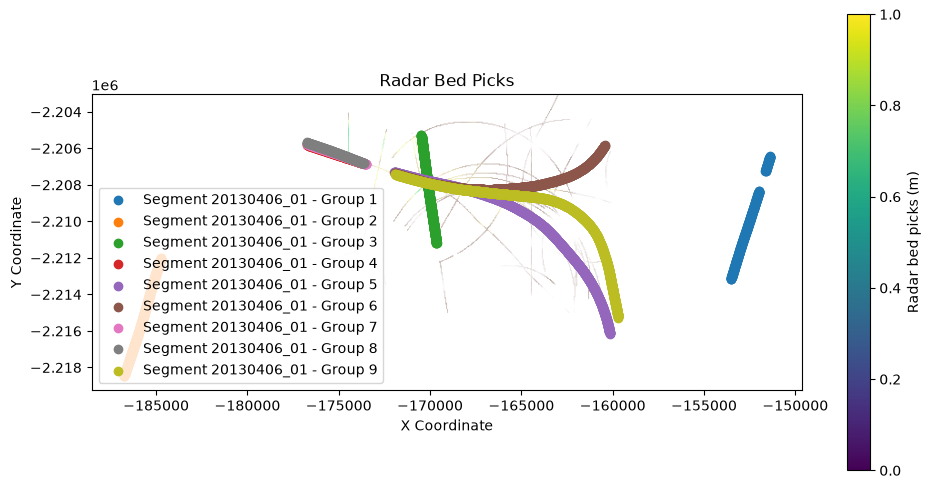

Available group keys: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  Group 1: 396 points, X range [-153523, -151383], Y range [-2213156, -2206433]
  Group 2: 452 points, X range [-186761, -184731], Y range [-2218472, -2212013]
  Group 3: 400 points, X range [-170478, -169643], Y range [-2211204, -2205273]
  Group 4: 213 points, X range [-176714, -173690], Y range [-2206807, -2205818]
  Group 5: 1054 points, X range [-171958, -160154], Y range [-2216143, -2207302]
  Group 6: 824 points, X range [-171931, -160438], Y range [-2208258, -2205840]
  Group 7: 230 points, X range [-176741, -173489], Y range [-2206867, -2205755]
  Group 8: 224 points, X range [-176762, -173619], Y range [-2206828, -2205677]
  Group 9: 1104 points, X range [-171905, -159689], Y range [-2215270, -2207427]


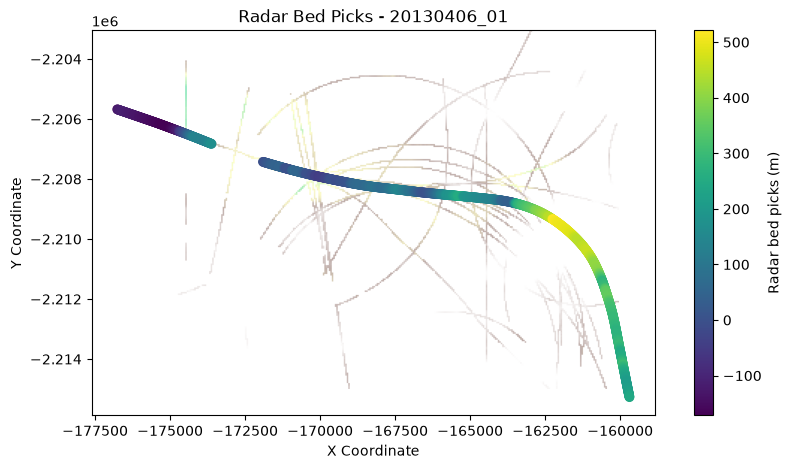

In [23]:
# candidate segments 
segment_candidates = ['20130406_01']

plt.figure(figsize=(10, 5))
plt.imshow(Z_interp, extent=extent, origin='lower', cmap='terrain', vmin=-400, vmax=400, alpha=0.5)
# plot the candidate segments
for segment in segment_candidates:
    segment_data = bed_picks[bed_picks['segment'] == segment]
    pices = (segment_data['Dist'] == 0).cumsum()
    segment_grouped = segment_data.groupby(pices)
    for name, segment_data in segment_grouped:
        plt.scatter(segment_data['X'], segment_data['Y'], 
                    cmap='terrain', vmin=-400, vmax=400,
                    label=f'Segment {segment} - Group {name}')
plt.colorbar(label='Radar bed picks (m)')
plt.legend()
plt.title('Radar Bed Picks')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.tight_layout()
plt.show()


segment_picked = ['20130406_01']

# FOLLOWING BLOCK IS SPECIFIC TO A SEGMENT
if segment_picked[0] == '20130406_01':
    # filter first, then compute groups on the filtered data
    segment_new = bed_picks[bed_picks['segment'].isin(segment_picked)].copy()
    segment_new_grouped = segment_new.groupby((segment_new['Dist'] == 0).cumsum())

    # inspect available groups
    keys = list(segment_new_grouped.groups.keys())
    print("Available group keys:", keys)
    for name, grp in segment_new_grouped:
        print(f"  Group {name}: {len(grp)} points, "
              f"X range [{grp['X'].min():.0f}, {grp['X'].max():.0f}], "
              f"Y range [{grp['Y'].min():.0f}, {grp['Y'].max():.0f}]")

    # combine all groups (or replace `keys` with a subset, e.g. keys[-2:])
    segment_new = pd.concat([segment_new_grouped.get_group(k) for k in [8,9]])
    segment_new = segment_new.reset_index(drop=True)

# visualize just the new segment
plt.figure(figsize=(10, 5))
plt.imshow(Z_interp, extent=extent, origin='lower', cmap='terrain', vmin=-400, vmax=400, alpha=0.5)
plt.scatter(segment_new['X'], segment_new['Y'], c=segment_new['bottom'], 
            cmap='viridis',
            label=f'Segment {segment_picked[0]} - All Groups')
plt.colorbar(label='Radar bed picks (m)')
plt.title(f'Radar Bed Picks - {segment_picked[0]}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


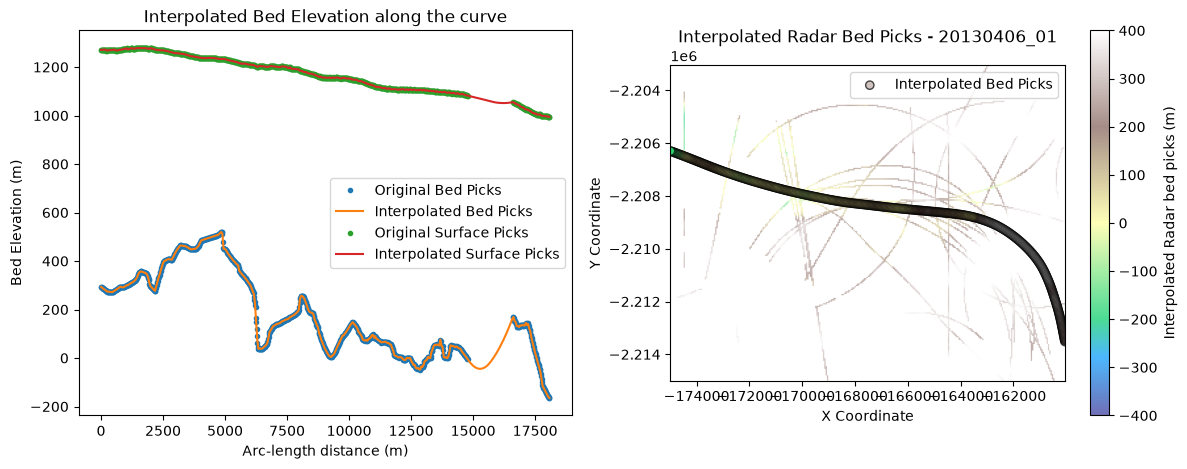

In [34]:
from scipy.interpolate import splprep, splev, interp1d

# crop the segment data to the extent of the stochastic bed
segment_picked_data_cropped = segment_new[(segment_new['X'] >= extent[0]) 
                                        & (segment_new['X'] <= extent[1]) 
                                        & (segment_new['Y'] >= extent[2]) 
                                        & (segment_new['Y'] <= extent[3])]

# THIS IS HARD WRIGING FOR THIS SPECIFIC SEGMENT
# recompute the distance wrt the lower right corner data point
lower_right_x = segment_picked_data_cropped['X'].max()
lower_right_y = segment_picked_data_cropped['Y'].min()
segment_picked_data_cropped['Dist'] = np.sqrt((segment_picked_data_cropped['X'] - lower_right_x) ** 2 
                                            + (segment_picked_data_cropped['Y'] - lower_right_y) ** 2)
# reorder based on the distance
segment_picked_data_cropped = segment_picked_data_cropped.sort_values(by='Dist')  

# interpolate x, y to a curve that is linearly spaced in x and y, and then interpolate the bed picks to that grid
curve_x = segment_picked_data_cropped['X'].values
curve_y = segment_picked_data_cropped['Y'].values
curve_bedz  = segment_picked_data_cropped['bottom'].values
curve_surfz = segment_picked_data_cropped['surface'].values

diffs = np.diff(np.column_stack([curve_x, curve_y]), axis=0)
seg_lengths = np.sqrt((diffs ** 2).sum(axis=1))
arc_length = np.concatenate([[0], np.cumsum(seg_lengths)])  # shape: (N,)
total_length = arc_length[-1]

# fit spline parameterized by arc-length
tck, _ = splprep([curve_x, curve_y], u=arc_length, s=0)

# sample at EQUALLY spaced arc-length intervals
n_points = 400  # adjust as needed
u_equal = np.linspace(0, total_length, n_points)
linear_x, linear_y = splev(u_equal, tck)

# first interpolate the original z values onto arc-length
bedz_interp_func  = interp1d(arc_length, curve_bedz, kind='quadratic', fill_value='extrapolate')
surfz_interp_func = interp1d(arc_length, curve_surfz, kind='quadratic', fill_value='extrapolate')
bed_picks_interp  = bedz_interp_func(u_equal)
surf_picks_interp = surfz_interp_func(u_equal)

# visuzlied
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
# use arc_length for original points — same parameterization as u_equal
plt.plot(arc_length, curve_bedz, 'o', markersize=3, label='Original Bed Picks')
plt.plot(u_equal, bed_picks_interp, '-', label='Interpolated Bed Picks')
plt.plot(arc_length, curve_surfz, 'o', markersize=3, label='Original Surface Picks')
plt.plot(u_equal, surf_picks_interp, '-', label='Interpolated Surface Picks')
plt.title('Interpolated Bed Elevation along the curve')
plt.xlabel('Arc-length distance (m)')
plt.ylabel('Bed Elevation (m)')
plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(Z_interp, extent=extent, origin='lower', cmap='terrain', vmin=-400, vmax=400, alpha=0.5)
plt.scatter(linear_x, linear_y, c=bed_picks_interp, cmap='terrain', edgecolor='k', 
            vmin=-400, vmax=400, alpha=0.7, label='Interpolated Bed Picks')
# plt.scatter(curve_x, curve_y, c=segment_picked_data_cropped['Dist'], cmap='viridis', 
#             alpha=0.7, label='Interpolated Bed Picks')
plt.colorbar(label='Interpolated Radar bed picks (m)')
plt.legend()
plt.title(f'Interpolated Radar Bed Picks - {segment_picked[0]}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# save the interpolated bed picks to a CSV file
interpolated_bed_picks_df = pd.DataFrame({
    'X': linear_x,
    'Y': linear_y,
    'Dist': u_equal,
    'bottom': bed_picks_interp,
    'surface': surf_picks_interp
})
interpolated_bed_picks_df.to_csv(f'../data/interpolated_bed_picks_{segment_picked[0]}.csv', index=False)